# 💚 Model PPG Baru — Transfer Learning dari EKG Data_new

**Prasyarat:** Jalankan `model_ekg_data_baru.ipynb` terlebih dahulu.

### Alur Alignment EKG ↔ PPG:
- Rekaman **multi-hari** → pakai `day × 86400 + jam` sebagai waktu absolut
- Satu file ECG per subjek, PPG terpecah jadi banyak sesi
- Matching temporal: peak PPG ↔ beat EKG terdekat dalam ±1.5 detik
- Label AF dipropagasi dari EKG ke PPG window

**Output:** `Model/model_ppg_datanew.keras`

In [1]:
# =====================================================================
# SEL 1: IMPORT & KONFIGURASI
# =====================================================================
import os, gc, glob, json, warnings
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy.signal import find_peaks, butter, filtfilt

warnings.filterwarnings('ignore')

try:
    import neurokit2 as nk
    HAS_NK2 = True
    print('neurokit2 tersedia — menggunakan metode Elgendi')
except ImportError:
    HAS_NK2 = False
    print('neurokit2 tidak tersedia — menggunakan scipy fallback')

DATA_DIR       = os.path.join(os.getcwd(), 'Data_new')
MODEL_DIR      = os.path.join(os.getcwd(), 'Model')
EKG_MODEL_PATH = os.path.join(MODEL_DIR, 'model_ekg_datanew.keras')
EKG_META_PATH  = os.path.join(MODEL_DIR, 'ekg_datanew_meta.json')
PPG_MODEL_OUT  = os.path.join(MODEL_DIR, 'model_ppg_datanew.keras')

if os.path.exists(EKG_META_PATH):
    with open(EKG_META_PATH) as f:
        meta = json.load(f)
    N_KELAS     = meta['n_kelas']
    WINDOW_SIZE = meta['window_size']
    FS_ECG      = meta['fs_ecg']
    NAMA_KELAS  = {int(k): v for k, v in meta['nama_kelas'].items()}
    print(f'Meta EKG dimuat: N_KELAS={N_KELAS}, WINDOW_SIZE={WINDOW_SIZE}, FS_ECG={FS_ECG}')
else:
    N_KELAS, WINDOW_SIZE, FS_ECG = 2, 30, 500
    NAMA_KELAS = {0: 'NSR', 1: 'AFib'}
    print('Menggunakan konfigurasi default')

FS_PPG         = 100
BATCH_SIZE     = 128
EPOCHS         = 80
LEARNING_RATE  = 5e-4
MAX_WEIGHT     = 10.0
SEED           = 42
tf.random.set_seed(SEED); np.random.seed(SEED)

neurokit2 tersedia — menggunakan metode Elgendi
Meta EKG dimuat: N_KELAS=2, WINDOW_SIZE=30, FS_ECG=500


In [5]:
# =====================================================================
# SEL 2: FUNGSI UTILITY — TIMESTAMP MULTI-HARI
# =====================================================================

def decode_h5_string(f, key):
    raw = f[key][()].flatten()
    return ''.join(chr(int(c)) for c in raw)

def recording_to_abs_seconds(day_str, time_str):
    try:
        day = int(day_str.strip())
        h, m, s = [int(x) for x in time_str.strip().split(':')]
        return day * 86400 + h * 3600 + m * 60 + s
    except Exception as e:
        print(f'  [WARN] Gagal parse: day={day_str!r} time={time_str!r}: {e}')
        return None

# ✅ SESUDAH — gunakan 'rr' (per-beat, dijamin sama panjang dengan af)
def load_ecg_beat_timeline(ecg_filepath, fs_ecg=500):
    with h5py.File(ecg_filepath, 'r') as f:
        day_str  = decode_h5_string(f, 'recording_startday')
        time_str = decode_h5_string(f, 'recording_starttime')
        rr       = f['rr'][()].flatten().astype(np.float64)   # detik, per-beat
        af       = f['AF_annotation'][()].flatten()
    start_abs = recording_to_abs_seconds(day_str, time_str)
    if start_abs is None: return None, None

    # Rekonstruksi waktu absolut tiap beat via cumulative sum RR
    beat_abs = start_abs + np.cumsum(rr)

    # Filter RR outlier (gap antar sesi) sebelum cumsum
    # — jika ada rr > 2.5s, waktu beat setelahnya masih benar
    # (tidak perlu dibuang di sini, cukup di windowing)

    # Pastikan panjang sama (guard)
    min_len  = min(len(beat_abs), len(af))
    beat_abs = beat_abs[:min_len]
    af       = af[:min_len]

    af_int = np.full(min_len, -1, dtype=np.int32)
    af_int[af == 0.0] = 0
    af_int[af == 1.0] = 1
    return beat_abs, af_int


def load_ppg_session(ppg_filepath, fs_ppg=100):
    with h5py.File(ppg_filepath, 'r') as f:
        day_str  = decode_h5_string(f, 'recording_startday')
        time_str = decode_h5_string(f, 'recording_starttime')
        ts_rec   = f['timestamp_sec_data_record'][()].flatten()
        ppg      = f['PPG_GREEN'][()].flatten()
        num_rec  = int(f['num_data_records'][()].flat[0])
    start_abs = recording_to_abs_seconds(day_str, time_str)
    if start_abs is None: return None, None, None
    n_samples = len(ppg)
    spr = n_samples / num_rec
    sample_abs = np.zeros(n_samples, dtype=np.float64)
    for i, t_rec in enumerate(ts_rec):
        i0 = int(round(i * spr)); i1 = min(int(round((i+1)*spr)), n_samples)
        n  = i1 - i0
        if n <= 0: continue
        sample_abs[i0:i1] = start_abs + (t_rec - 1.0) + np.arange(n) / spr
    return start_abs, ppg, sample_abs

print('Fungsi utility timestamp siap.')

Fungsi utility timestamp siap.


Quick check PPG (60s): 15 peaks | HR est: 14.4 BPM


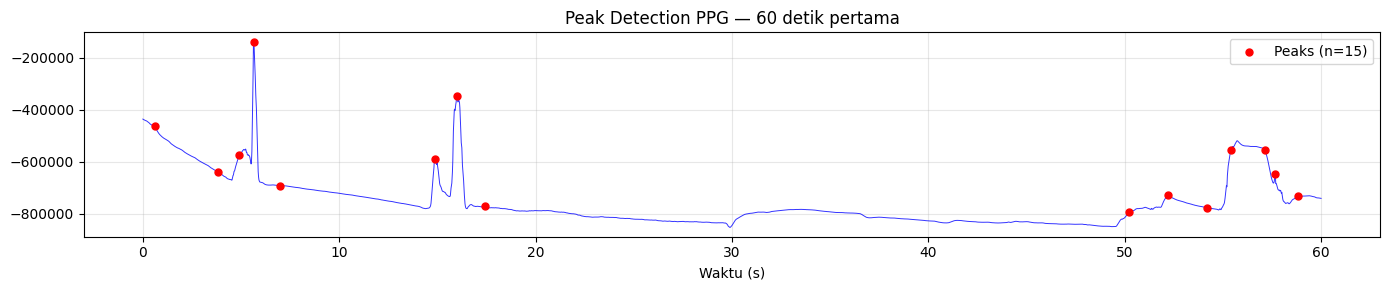

In [6]:
# =====================================================================
# SEL 3: FUNGSI DETEKSI PEAK PPG
# =====================================================================

def filter_ppg(sig, fs, lo=0.5, hi=8.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lo/nyq, min(hi/nyq, 0.99)], btype='band')
    return filtfilt(b, a, sig)

def deteksi_peak_ppg(ppg_signal, fs, min_dist_s=0.4):
    if HAS_NK2:
        try:
            ppg_c = nk.ppg_clean(ppg_signal, sampling_rate=int(fs))
            info  = nk.ppg_findpeaks(ppg_c, sampling_rate=int(fs), method='elgendi')
            peaks = np.array(info['PPG_Peaks'])
            if len(peaks) > 5: return peaks
        except: pass
    ppg_f = filter_ppg(ppg_signal, fs)
    thr   = np.percentile(ppg_f, 55)
    peaks, _ = find_peaks(ppg_f, distance=int(min_dist_s * fs), height=thr)
    return peaks

def propagasi_label_ppg(ppg_peak_abs, ecg_beat_abs, af_labels, tol_s=1.5):
    labels = np.full(len(ppg_peak_abs), -1, dtype=np.int32)
    for i, t in enumerate(ppg_peak_abs):
        idx = np.searchsorted(ecg_beat_abs, t)
        best_l, best_d = -1, tol_s
        for c in [idx-1, idx]:
            if 0 <= c < len(ecg_beat_abs):
                d = abs(ecg_beat_abs[c] - t)
                if d < best_d and af_labels[c] != -1:
                    best_d, best_l = d, int(af_labels[c])
        labels[i] = best_l
    return labels

# Quick check
ppg_test_fp = sorted(glob.glob(os.path.join(DATA_DIR, '01_PPG_*.mat')))[0]
_, ppg_test, _ = load_ppg_session(ppg_test_fp, FS_PPG)
seg = ppg_test[:int(60 * FS_PPG)]
peaks_test = deteksi_peak_ppg(seg, FS_PPG)
rr_test    = np.diff(peaks_test) / FS_PPG
print(f'Quick check PPG (60s): {len(peaks_test)} peaks | HR est: {60/rr_test.mean():.1f} BPM')

fig, ax = plt.subplots(figsize=(14, 3))
t = np.arange(len(seg)) / FS_PPG
ax.plot(t, seg, 'b-', lw=0.7, alpha=0.8)
ax.scatter(peaks_test/FS_PPG, seg[peaks_test], c='red', s=25, zorder=5, label=f'Peaks (n={len(peaks_test)})')
ax.set_xlabel('Waktu (s)'); ax.set_title('Peak Detection PPG — 60 detik pertama')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
# =====================================================================
# SEL 4: ALIGNMENT EKG ↔ PPG & BUILD DATASET
# =====================================================================

def proses_ppg_subjek(ecg_fp, ppg_fps, fs_ecg=500, fs_ppg=100,
                      window_size=30, n_kelas=2):
    beat_abs, af_int = load_ecg_beat_timeline(ecg_fp, fs_ecg)
    if beat_abs is None:
        print('  [SKIP] Gagal load ECG'); return None, None

    valid_mask  = af_int != -1
    beat_abs_v  = beat_abs[valid_mask]
    af_int_v    = af_int[valid_mask]
    ecg_start   = beat_abs[0]
    ecg_end     = beat_abs[-1]
    print(f'  ECG: {valid_mask.sum():,}/{len(af_int):,} beat valid')

    X_all, y_all = [], []
    for ppg_fp in ppg_fps:
        fname = os.path.basename(ppg_fp)
        start_ppg, ppg_sig, sample_abs = load_ppg_session(ppg_fp, fs_ppg)
        if start_ppg is None:
            print(f'    [SKIP] {fname}: gagal load'); continue

        ppg_end = sample_abs[-1]
        if ppg_end < ecg_start - 60 or start_ppg > ecg_end + 60:
            print(f'    [SKIP] {fname}: tidak overlap dengan ECG'); continue

        try:
            peaks = deteksi_peak_ppg(ppg_sig, fs_ppg)
        except Exception as e:
            print(f'    [SKIP] {fname}: error peak: {e}'); continue

        if len(peaks) < window_size + 10:
            print(f'    [SKIP] {fname}: peaks terlalu sedikit ({len(peaks)})'); continue

        peak_abs   = sample_abs[peaks]
        rr_ppg     = np.diff(peak_abs)
        labels_ppg = propagasi_label_ppg(peak_abs[1:], beat_abs_v, af_int_v, tol_s=1.5)
        rr_diff    = np.diff(rr_ppg)

        n_ok = 0
        for i in range(window_size, len(rr_diff)):
            window = rr_diff[i - window_size: i]
            label  = labels_ppg[i-1] if (i-1) < len(labels_ppg) else -1
            if label not in range(n_kelas): continue
            if np.any(np.isnan(window)):    continue
            if np.any(np.abs(window) > 1.0): continue
            X_all.append(window.astype(np.float32))
            y_all.append(label); n_ok += 1

        n0 = sum(1 for l in y_all[-n_ok:] if l == 0) if n_ok else 0
        n1 = sum(1 for l in y_all[-n_ok:] if l == 1) if n_ok else 0
        print(f'    {fname}: peaks={len(peaks)} | ok={n_ok} | NSR={n0} AF={n1}')
        gc.collect()

    if not X_all: return None, None
    X = np.array(X_all, np.float32).reshape(-1, window_size, 1)
    y = np.array(y_all, np.int32)
    return X, y


ecg_files = sorted(glob.glob(os.path.join(DATA_DIR, '*_ECG_01.mat')))
X_all_ppg, y_all_ppg = [], []

for ecg_fp in ecg_files:
    subj = os.path.basename(ecg_fp)[:2]
    print(f'\n=== Subjek {subj} ===')
    ppg_fps = sorted(glob.glob(os.path.join(DATA_DIR, f'{subj}_PPG_*.mat')))
    if not ppg_fps:
        print('  [SKIP] Tidak ada file PPG'); continue

    X_s, y_s = proses_ppg_subjek(ecg_fp, ppg_fps, FS_ECG, FS_PPG, WINDOW_SIZE, N_KELAS)
    if X_s is None:
        print('  [SKIP] Tidak ada data valid'); continue

    X_all_ppg.append(X_s); y_all_ppg.append(y_s)
    print(f'  => {len(y_s):,} sampel | NSR={np.sum(y_s==0):,} AF={np.sum(y_s==1):,}')
    gc.collect()

if not X_all_ppg:
    raise RuntimeError('Tidak ada data PPG valid! Periksa timestamp alignment.')

X_ppg = np.concatenate(X_all_ppg)
y_ppg = np.concatenate(y_all_ppg)

print(f'\n=== TOTAL DATASET PPG ===')
print(f'Shape: {X_ppg.shape}')
for k, nm in NAMA_KELAS.items():
    n = np.sum(y_ppg == k)
    print(f'  {nm}: {n:,} ({100*n/len(y_ppg):.1f}%)')

X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_ppg, y_ppg, test_size=0.2, stratify=y_ppg, random_state=SEED
)
print(f'\nTrain: {len(y_tr):,} | Val: {len(y_vl):,}')
del X_all_ppg, y_all_ppg; gc.collect()


=== Subjek 01 ===
  ECG: 781,724/781,724 beat valid
    01_PPG_01.mat: peaks=9518 | ok=128 | NSR=128 AF=0
    01_PPG_02.mat: peaks=31231 | ok=8432 | NSR=8432 AF=0
    01_PPG_03.mat: peaks=15492 | ok=225 | NSR=225 AF=0
    01_PPG_04.mat: peaks=24035 | ok=5028 | NSR=5028 AF=0
    01_PPG_05.mat: peaks=10649 | ok=77 | NSR=77 AF=0
    01_PPG_06.mat: peaks=10813 | ok=481 | NSR=481 AF=0
    01_PPG_07.mat: peaks=3413 | ok=0 | NSR=0 AF=0
    01_PPG_08.mat: peaks=8508 | ok=292 | NSR=292 AF=0
    01_PPG_09.mat: peaks=5105 | ok=209 | NSR=209 AF=0
    01_PPG_10.mat: peaks=11464 | ok=4821 | NSR=4821 AF=0
  => 19,693 sampel | NSR=19,693 AF=0

=== Subjek 02 ===
  ECG: 664,935/665,226 beat valid
    02_PPG_01.mat: peaks=513 | ok=133 | NSR=133 AF=0
    02_PPG_02.mat: peaks=7623 | ok=270 | NSR=270 AF=0
    02_PPG_03.mat: peaks=40733 | ok=28375 | NSR=28375 AF=0
    02_PPG_04.mat: peaks=14696 | ok=3031 | NSR=3031 AF=0
    02_PPG_05.mat: peaks=49732 | ok=23140 | NSR=23140 AF=0
    02_PPG_06.mat: peaks=4783

0

In [10]:
# =====================================================================
# SEL 5: ARSITEKTUR MODEL PPG + TRANSFER LEARNING
# =====================================================================

class ClassToken(layers.Layer):
    def build(self, input_shape):
        # FIX: name harus keyword argument di TF >= 2.16
        self.cls = self.add_weight(
            name='cls_token',
            shape=(1, 1, input_shape[-1]),
            initializer='random_normal',
            trainable=True
        )
    def call(self, x):
        b = tf.shape(x)[0]
        return tf.concat([tf.broadcast_to(self.cls, [b, 1, x.shape[-1]]), x], axis=1)

def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, drop=0.2):
    a = layers.LayerNormalization(epsilon=1e-6)(x)
    a = layers.MultiHeadAttention(num_heads, head_size, dropout=drop)(a, a)
    a = layers.Dropout(drop)(a); r = a + x
    b = layers.LayerNormalization(epsilon=1e-6)(r)
    b = layers.Dense(ff_dim, 'relu')(b)
    b = layers.Dropout(drop)(b)
    b = layers.Dense(x.shape[-1])(b)
    return b + r

def bangun_model_ppg(input_shape=(WINDOW_SIZE, 1), n_kelas=N_KELAS,
                     filters=50, kernel=4, head_size=64,
                     num_heads=4, ff_dim=128, n_blocks=2, drop=0.2):
    inp = layers.Input(shape=input_shape, name='input_rr_diff')
    # Nama sama dengan EKG -> menerima transfer weight
    x = layers.Conv1D(filters, kernel, padding='causal',
                      activation='relu', name='cnn_lokal_1')(inp)
    x = layers.BatchNormalization()(x)
    # Layer baru khusus PPG
    x = layers.Conv1D(filters, kernel, padding='causal',
                      activation='relu', name='cnn_lokal_2_ppg')(x)
    x = layers.BatchNormalization()(x)
    seq = x.shape[1]
    pos = layers.Embedding(seq, filters, name='pos_embedding')(tf.range(seq))
    x = x + pos
    x = ClassToken(name='cls_token_layer')(x)
    for _ in range(n_blocks):
        x = transformer_block(x, head_size, num_heads, ff_dim, drop)
    x   = x[:, 0, :]
    x   = layers.Dense(64, 'relu')(x)
    x   = layers.Dropout(drop)(x)
    out = layers.Dense(n_kelas, 'softmax', name='output')(x)
    return Model(inp, out, name='PPG_HybridCNNTransformer_DataNew')

model_ppg = bangun_model_ppg()

if os.path.exists(EKG_MODEL_PATH):
    print(f'Transfer learning dari: {EKG_MODEL_PATH}')
    model_ekg = tf.keras.models.load_model(
        EKG_MODEL_PATH, custom_objects={'ClassToken': ClassToken}
    )
    # Buat dict {nama_layer: layer} dari model EKG
    ekg_layer_map = {l.name: l for l in model_ekg.layers}
    n_copied = 0
    for layer in model_ppg.layers:
        if layer.name in ekg_layer_map:
            src = ekg_layer_map[layer.name]
            if len(src.weights) == len(layer.weights):
                layer.set_weights(src.get_weights())
                n_copied += 1
                print(f'  ✓ Copied: {layer.name}')
            else:
                print(f'  ✗ Skip (shape mismatch): {layer.name}')
    print(f'\nTotal layer ter-copy: {n_copied}')
    del model_ekg  # bebaskan memori
    FREEZE = {'cnn_lokal_1', 'pos_embedding', 'cls_token_layer'}
    for l in model_ppg.layers:
        l.trainable = l.name not in FREEZE
    print('Fase 1 — layer di-freeze:', FREEZE)
else:
    print('[WARN] Model EKG tidak ditemukan, training dari nol')

model_ppg.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)
model_ppg.summary()

Transfer learning dari: c:\Users\Farel\Documents\Kuliah\Project\Cerevia\Model\model_ekg_datanew.keras
  ✓ Copied: input_rr_diff
  ✓ Copied: cnn_lokal_1
  ✓ Copied: cls_token_layer
  ✓ Copied: output

Total layer ter-copy: 4
Fase 1 — layer di-freeze: {'pos_embedding', 'cls_token_layer', 'cnn_lokal_1'}


Model: "PPG_HybridCNNTransformer_DataNew"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_rr_diff       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_lokal_1         │ (None, 30, 50)    │        250 │ input_rr_diff[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 50)    │        200 │ cnn_lokal_1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_lokal_2_ppg     │ (None, 30, 50)    │     10,050 │ batch_normalizat… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 50)    │        200 │ cnn_lokal_2_ppg[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 30, 50)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_token_layer     │ (None, 31, 50)    │         50 │ add_6[0][0]       │
│ (ClassToken)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 50)    │        100 │ cls_token_layer[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 50)    │     52,018 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 31, 50)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 31, 50)    │          0 │ dropout_8[0][0],  │
│                     │                   │            │ cls_token_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 50)    │        100 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 31, 128)   │      6,528 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 31, 128)   │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 31, 50)    │      6,450 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 31, 50)    │          0 │ dense_6[0][0],    │
│                     │                   │            │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 50)    │        100 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 50)    │     52,018 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 144,536 (564.59 KB)

 Trainable params: 144,036 (562.64 KB)

 Non-trainable params: 500 (1.95 KB)

In [11]:
# =====================================================================
# SEL 6: TRAINING DUA FASE
# =====================================================================

cw  = compute_class_weight('balanced', classes=np.arange(N_KELAS), y=y_tr)
cw  = np.clip(cw, 1.0, MAX_WEIGHT)
cwd = {i: float(w) for i, w in enumerate(cw)}
print('Class weights:', {NAMA_KELAS[k]: f'{v:.2f}' for k, v in cwd.items()})

def balanced_ds(X, y, bs, nk, seed=42):
    dsl = []
    for k in range(nk):
        idx = np.where(y == k)[0]
        if not len(idx): continue
        ds = tf.data.Dataset.from_tensor_slices((X[idx], y[idx]))
        dsl.append(ds.shuffle(len(idx), seed=seed, reshuffle_each_iteration=True).repeat())
    w = [1.0/len(dsl)] * len(dsl)
    return tf.data.Dataset.sample_from_datasets(dsl, weights=w, seed=seed)\
             .batch(bs).prefetch(tf.data.AUTOTUNE)

ds_tr  = balanced_ds(X_tr, y_tr, BATCH_SIZE, N_KELAS)
ds_vl  = tf.data.Dataset.from_tensor_slices((X_vl, y_vl))\
           .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
STEPS  = max(100, len(y_tr) // BATCH_SIZE)

def make_callbacks():
    return [
        ModelCheckpoint(PPG_MODEL_OUT, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=12,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=6, min_lr=1e-7, verbose=1)
    ]

print('\n' + '='*55)
print('FASE 1: Layer PPG baru + head (layer EKG di-freeze)')
print('='*55)
h1 = model_ppg.fit(ds_tr, epochs=30, steps_per_epoch=STEPS,
                   validation_data=ds_vl, callbacks=make_callbacks(),
                   class_weight=cwd, verbose=1)

print('\n' + '='*55)
print('FASE 2: Fine-tune semua layer (LR kecil)')
print('='*55)
for l in model_ppg.layers: l.trainable = True
model_ppg.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE * 0.1),
    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h2 = model_ppg.fit(ds_tr, epochs=EPOCHS, steps_per_epoch=STEPS,
                   validation_data=ds_vl, callbacks=make_callbacks(),
                   class_weight=cwd, verbose=1)

print(f'\n✅ Model PPG terbaik: {PPG_MODEL_OUT}')

Class weights: {'NSR': '1.00', 'AFib': '10.00'}

FASE 1: Layer PPG baru + head (layer EKG di-freeze)
Epoch 1/30
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9474 - loss: 0.3429
Epoch 1: val_accuracy improved from None to 0.99702, saving model to c:\Users\Farel\Documents\Kuliah\Project\Cerevia\Model\model_ppg_datanew.keras

Epoch 1: finished saving model to c:\Users\Farel\Documents\Kuliah\Project\Cerevia\Model\model_ppg_datanew.keras
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 201s 66ms/step - accuracy: 0.9739 - loss: 0.1670 - val_accuracy: 0.9970 - val_loss: 0.0151 - learning_rate: 5.0000e-04
Epoch 2/30
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9939 - loss: 0.0329
Epoch 2: val_accuracy did not improve from 0.99702
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 192s 64ms/step - accuracy: 0.9948 - loss: 0.0292 - val_accuracy: 0.9864 - val_loss: 0.0929 - learning_rate: 5.0000e-04
Epoch 3/30
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9950 - loss: 0.0261
Epoch 3: val_accuracy

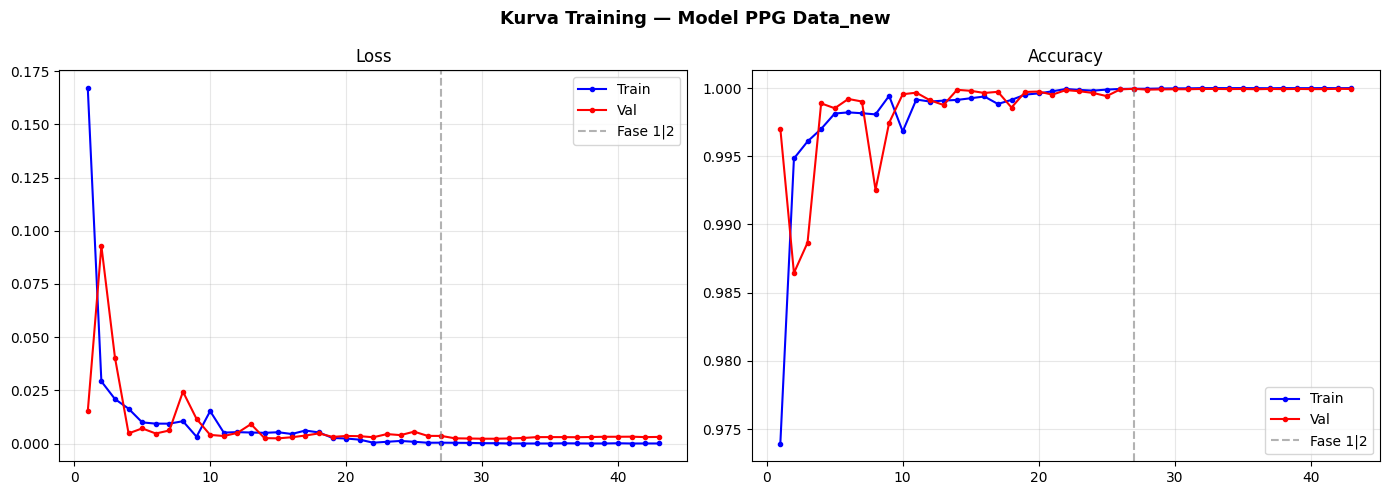


=== Classification Report (PPG Data_new) ===
              precision    recall  f1-score   support

         NSR       1.00      1.00      1.00     95463
        AFib       1.00      0.94      0.97        86

    accuracy                           1.00     95549
   macro avg       1.00      0.97      0.99     95549
weighted avg       1.00      1.00      1.00     95549



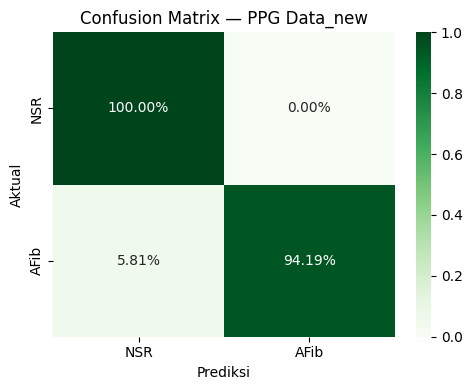


✅ Selesai! Model: c:\Users\Farel\Documents\Kuliah\Project\Cerevia\Model\model_ppg_datanew.keras


In [12]:
# =====================================================================
# SEL 7: EVALUASI & VISUALISASI
# =====================================================================

nama_list = [NAMA_KELAS[k] for k in range(N_KELAS)]
n_p1 = len(h1.history['loss'])
hist = {k: h1.history[k] + h2.history.get(k, []) for k in h1.history}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kurva Training — Model PPG Data_new', fontsize=13, fontweight='bold')
ep = range(1, len(hist['loss'])+1)
for i, (m, t) in enumerate([('loss', 'Loss'), ('accuracy', 'Accuracy')]):
    ax = axes[i]
    ax.plot(ep, hist[m],          'b-o', ms=3, label='Train')
    ax.plot(ep, hist[f'val_{m}'], 'r-o', ms=3, label='Val')
    ax.axvline(n_p1, color='gray', ls='--', alpha=0.6, label='Fase 1|2')
    ax.set_title(t); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'kurva_training_ppg_datanew.png'), dpi=150, bbox_inches='tight')
plt.show()

best = tf.keras.models.load_model(PPG_MODEL_OUT, custom_objects={'ClassToken': ClassToken})
yp   = np.argmax(best.predict(ds_vl, verbose=0), axis=1)
print('\n=== Classification Report (PPG Data_new) ===')
print(classification_report(y_vl, yp, target_names=nama_list))

cm = confusion_matrix(y_vl, yp)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm/cm.sum(axis=1, keepdims=True), annot=True, fmt='.2%',
            cmap='Greens', xticklabels=nama_list, yticklabels=nama_list, ax=ax)
ax.set_title('Confusion Matrix — PPG Data_new')
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix_ppg_datanew.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ Selesai! Model: {PPG_MODEL_OUT}')